## Multi-head attention

Теперь, когда вы полностью поняли механизм самовнимания с обучаемыми весами, давайте сделаем его ещё мощнее.

В предыдущей главе мы реализовали одно внимание (Single-Head Attention). Это как если бы у вас был один эксперт, который анализирует текст.

Пример:

`«Кот любил сметану, потому что он был вкусный»`

Один механизм внимания может научиться, что «он» → «сметана». Но что если мы хотим одновременно понять:

1. Грамматическую связь: «он» → «сметана» (род, число)
2. Семантическую связь: «любил» → «кот» (кто выполняет действие)
3. Синтаксическую связь: «любил» → «сметану» (что является объектом)

Один механизм внимания вынужден выбирать одну стратегию. Это как если бы один человек пытался одновременно быть грамматиком, лингвистом и литературным критиком.

**Решение: Несколько «голов» внимания**

**Multi-Head Attention** - это как нанять несколько экспертов, каждый из которых смотрит на текст под своим углом:

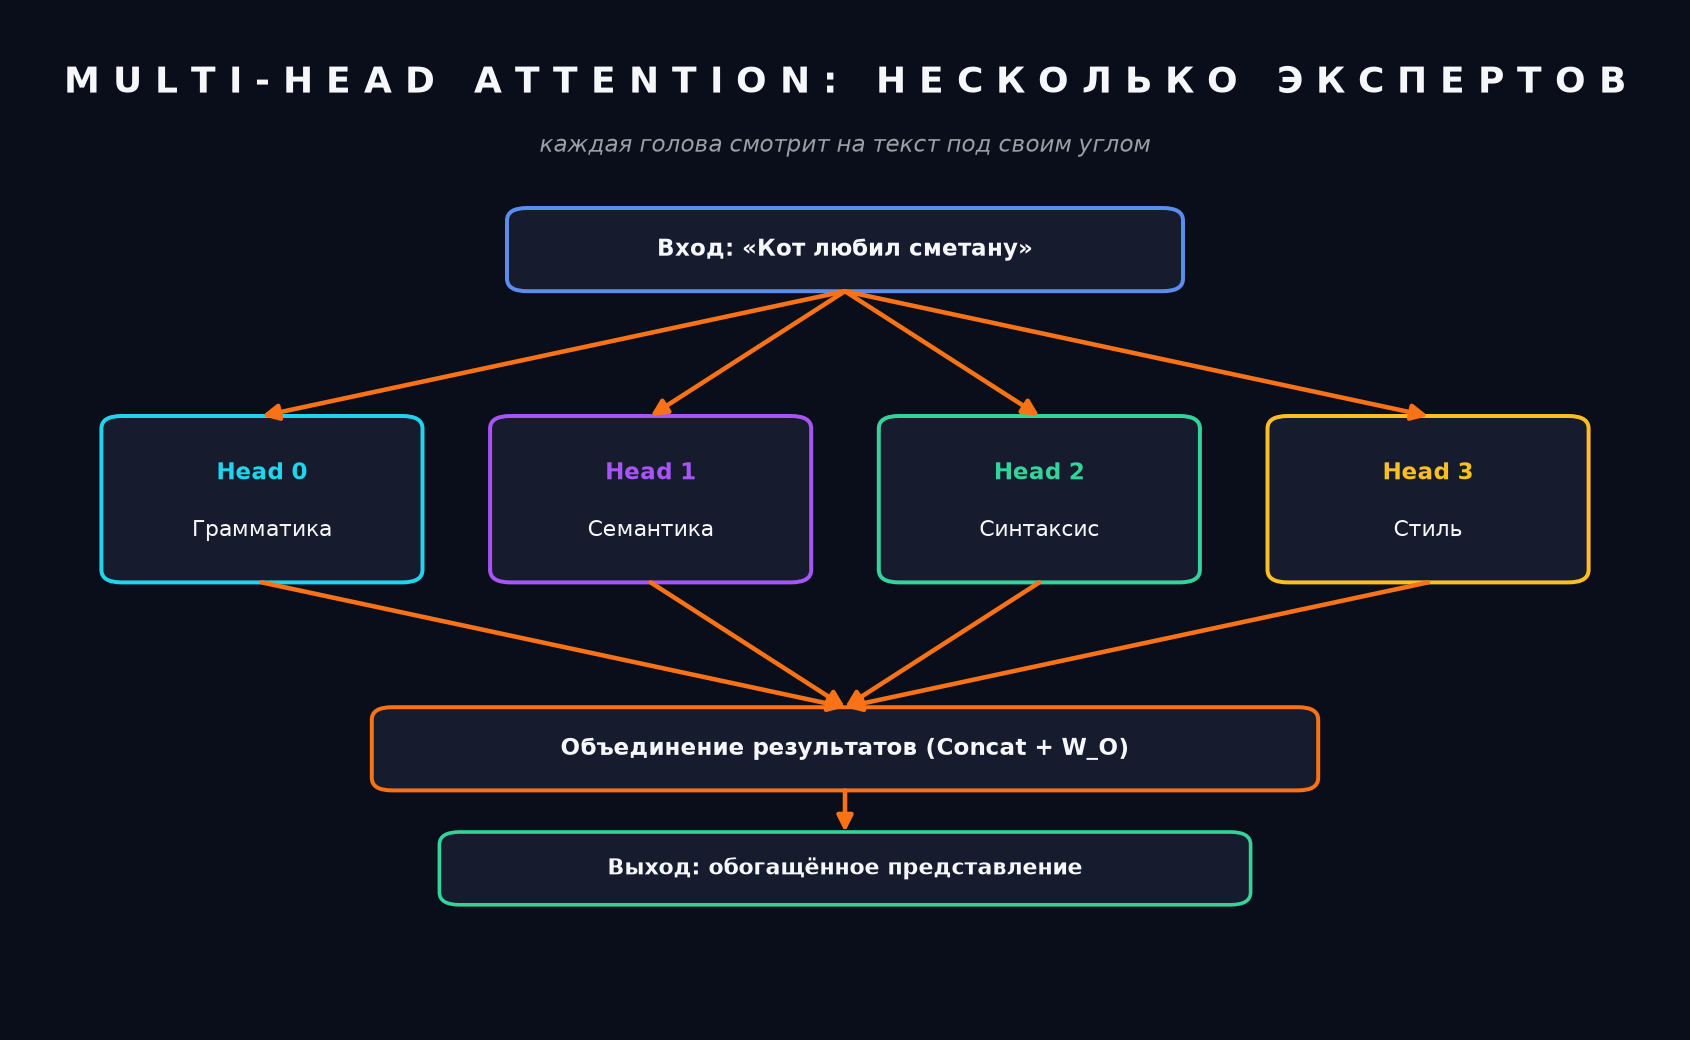

Таким образом, мы можем получить - **Параллелизм, Разнообразие и Выразительность**

### Ключевая идея: Разделение размерности

Вместо того чтобы каждая голова работала с полной размерностью `embed_dim`, мы делим её на `num_heads` частей.

Пример:

In [ ]:
embed_dim = 16   # (размер вектора токена)
num_heads = 2    # (количество голов)
head_dim = 16 / 2   #(размер каждой головы)

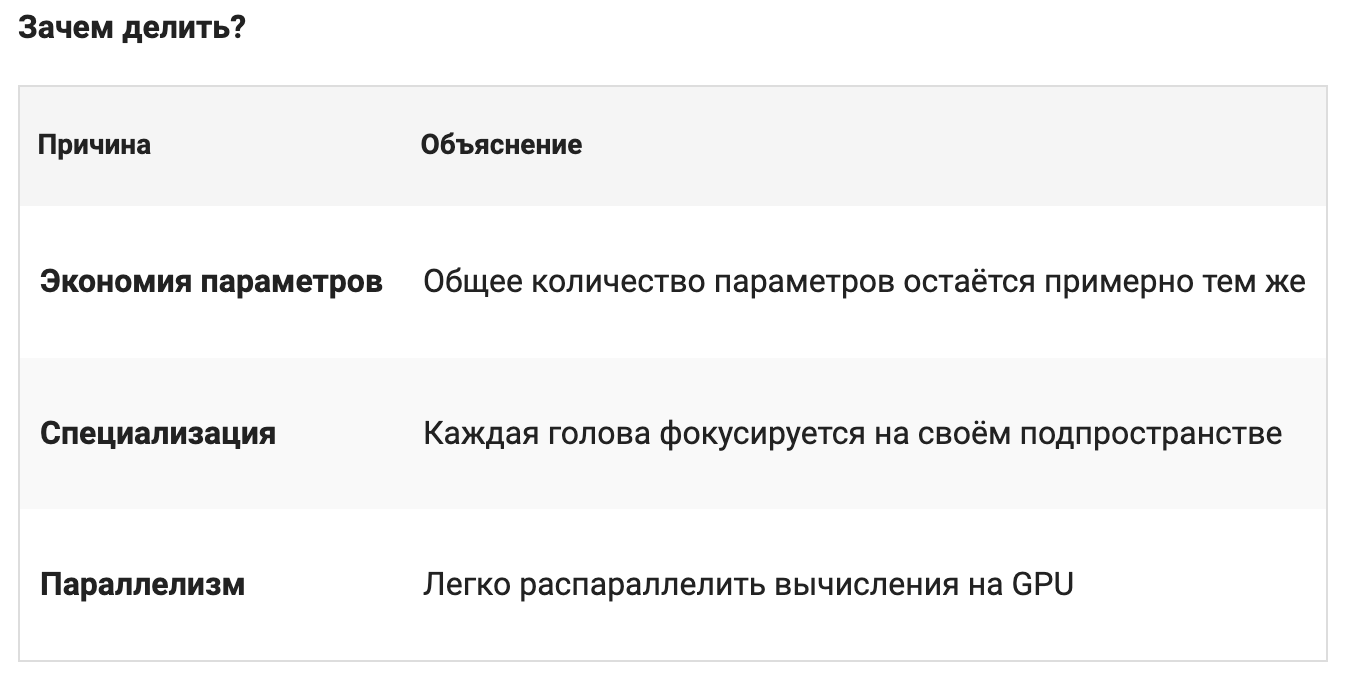

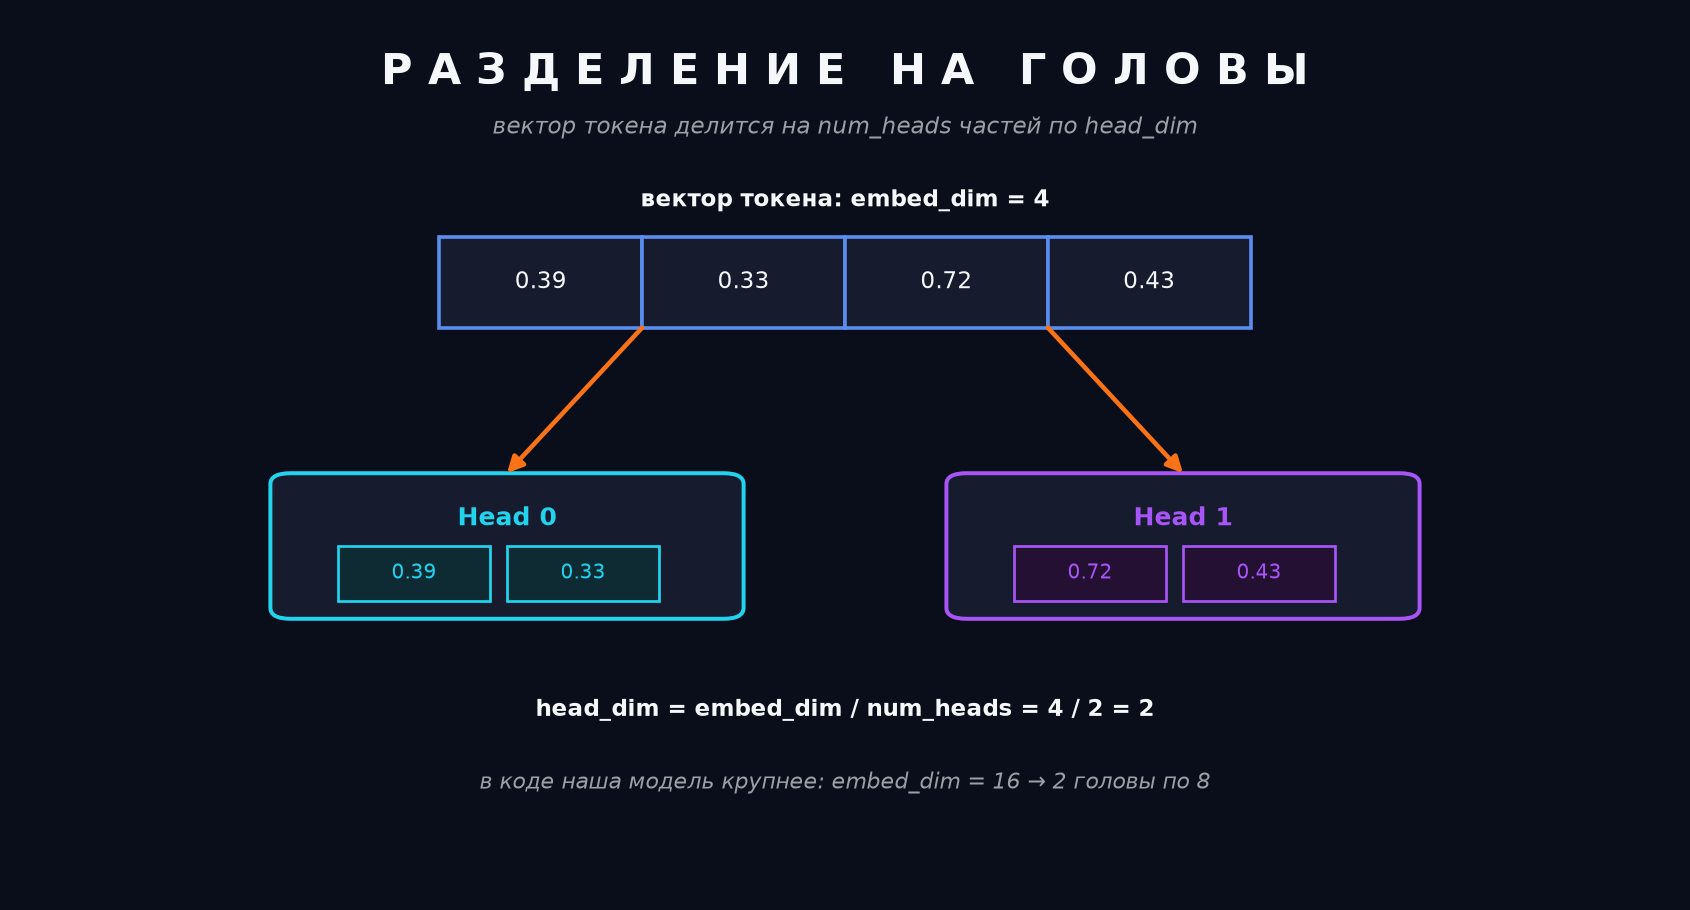

**Полная архитектура**

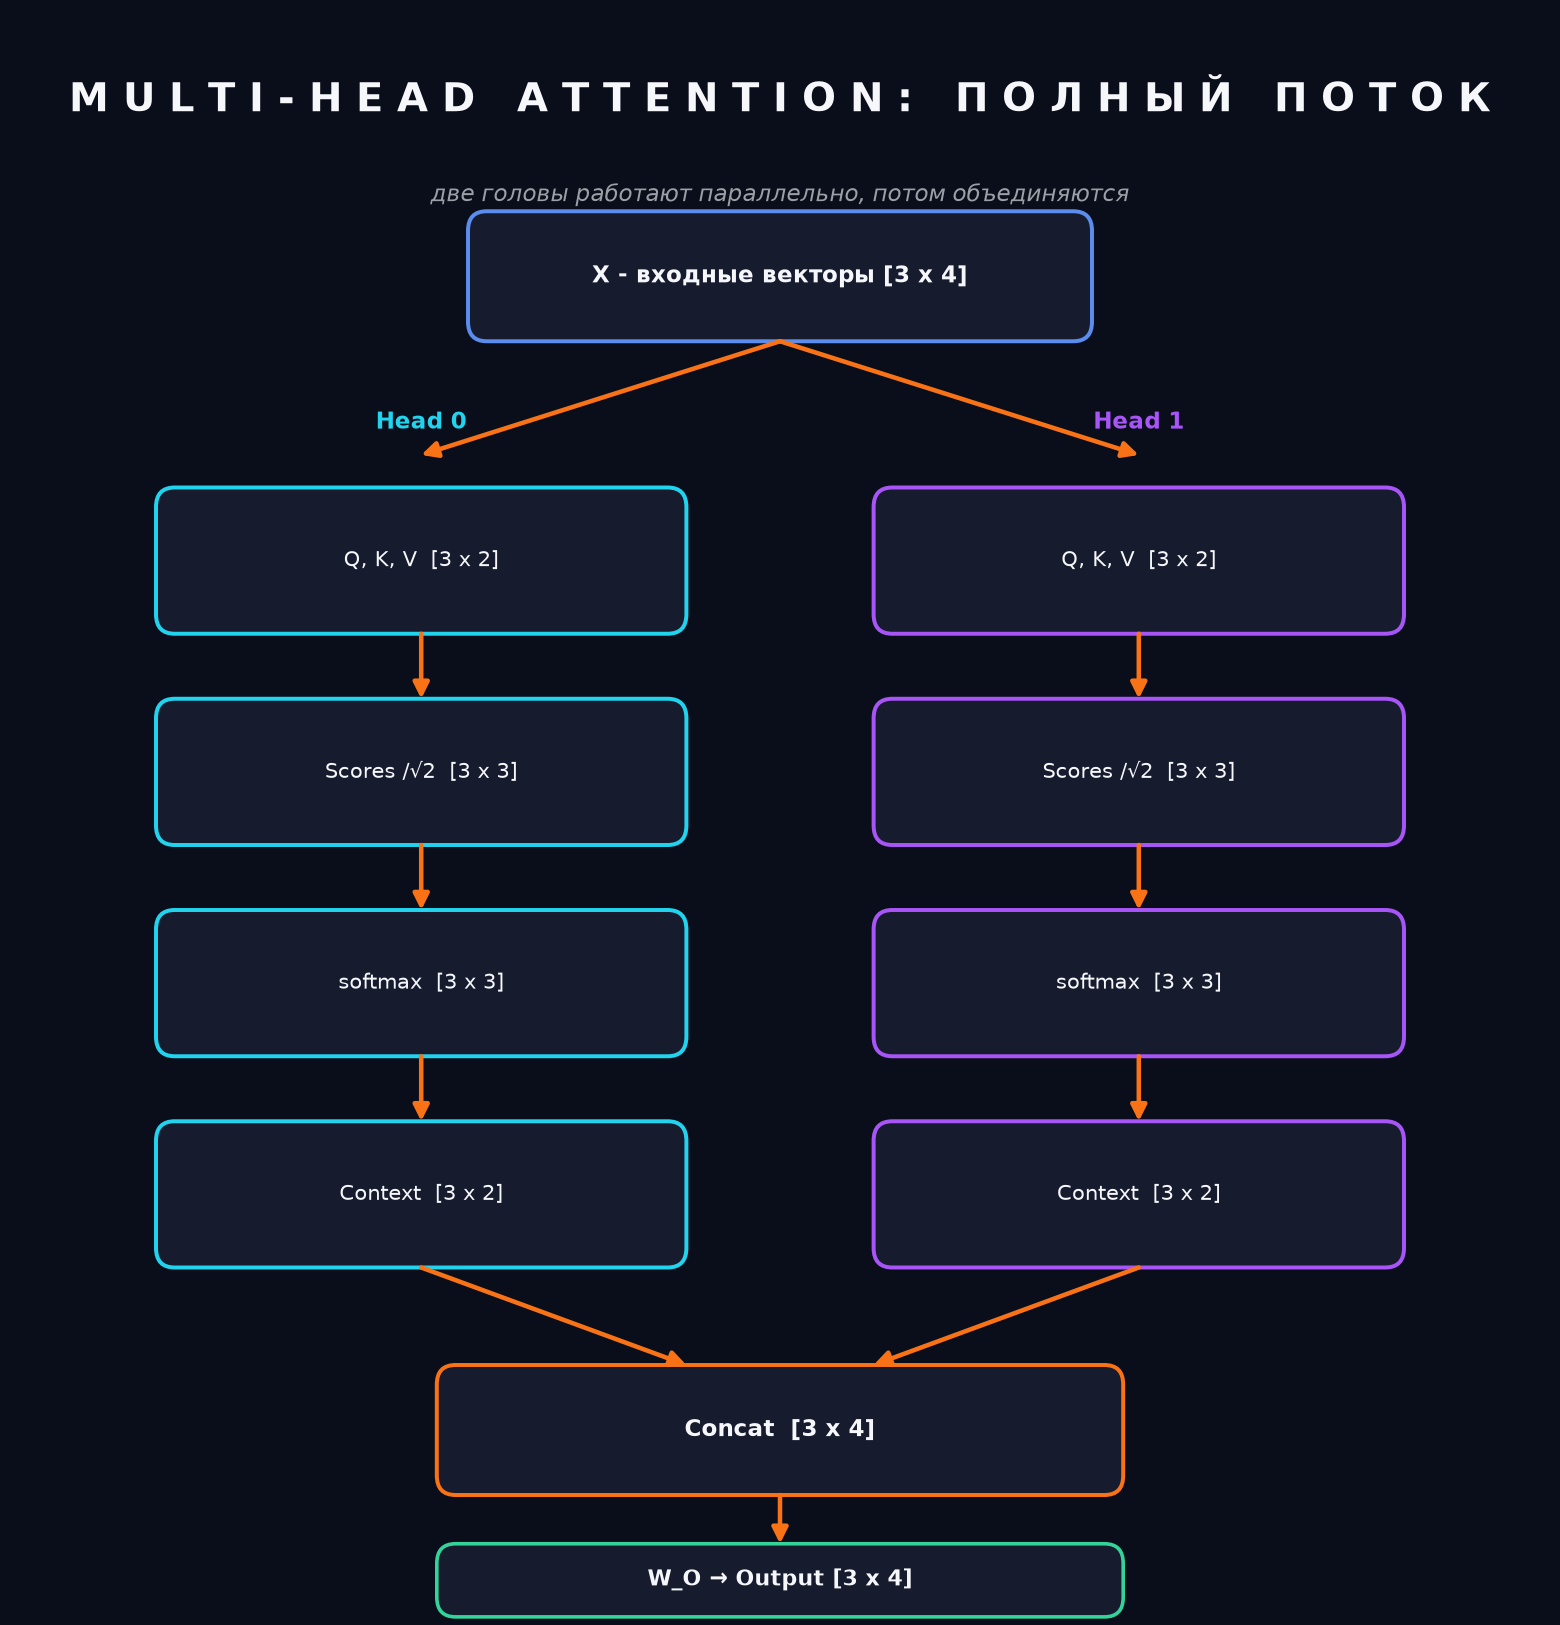

Возьмём то же предложение для сравнения с предыдущими главами:

`«The cat loved»`

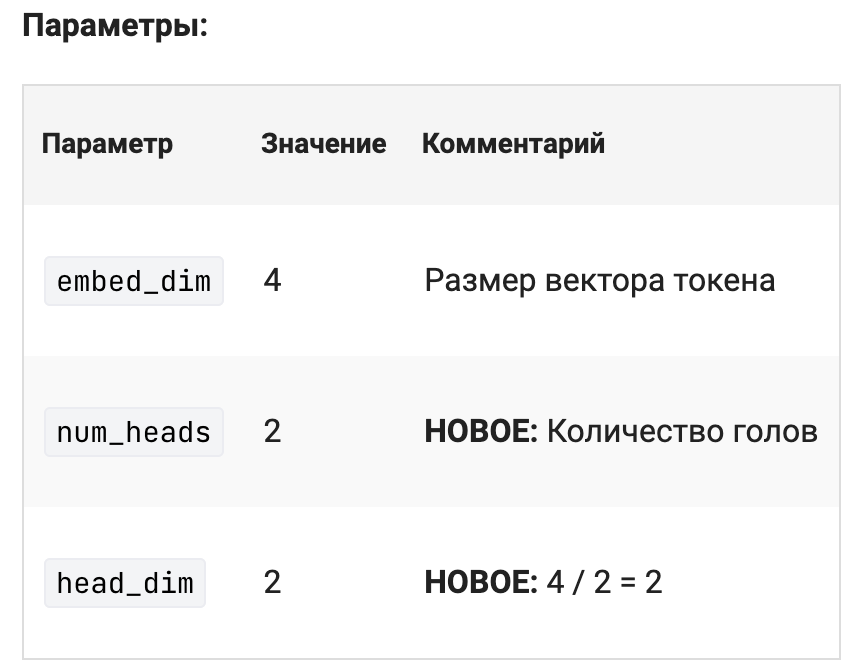

**Примечание про размерность:** для ручного счёта мы берём маленькие числа - `embed_dim = 4`, `head_dim = 2`, чтобы всё удобно считалось на бумаге. В коде (последний урок модуля) наша учебная модель будет крупнее - `embed_dim = 16`, `head_dim = 8`, но механика ровно та же.

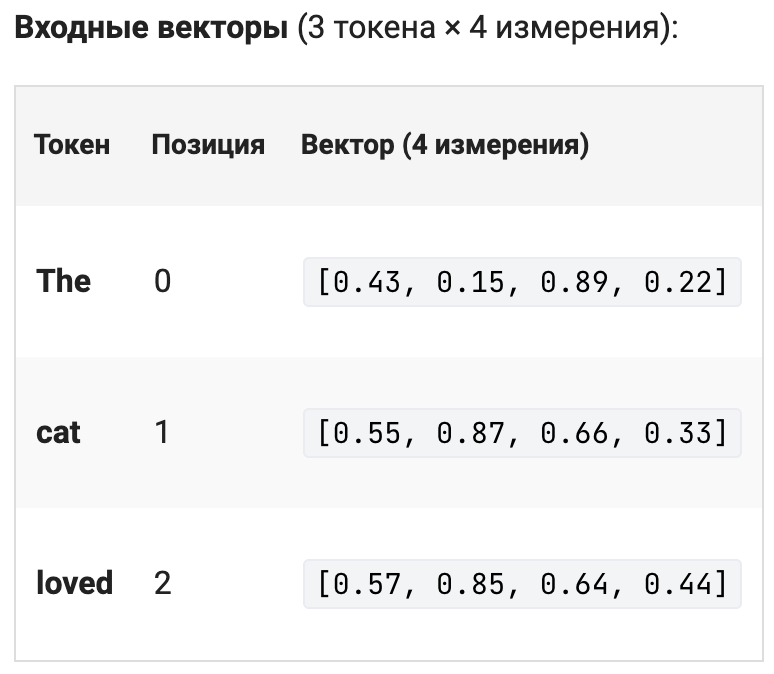

**Матрица входных данных $X$:**

$$
X =
\begin{bmatrix}
0.43 & 0.15 & 0.89 & 0.22 \\
0.55 & 0.87 & 0.66 & 0.33 \\
0.57 & 0.85 & 0.64 & 0.44
\end{bmatrix}
$$

В **Single-Head Attention** - У нас было 3 матрицы, каждая размером `[embed_dim, embed_dim] = [4, 4]`

**В Multi-Head теперь 2 головы, и для каждой нужны свои матрицы $W_Q, W_K, W_V$**

**Важное отличие:** Размер матриц теперь [embed_dim, head_dim] = [4, 2], а не [4, 4]!

**Head 0 (head_dim = 2)**

$$
W_Q^{(0)} =
\begin{bmatrix}
0.5 & 0.2 \\
0.3 & 0.6 \\
0.1 & 0.1 \\
0.2 & 0.3
\end{bmatrix}
$$

$$
W_Q^{(0)} =
\begin{bmatrix}
0.5 & 0.2 \\
0.3 & 0.6 \\
0.1 & 0.1 \\
0.2 & 0.3
\end{bmatrix}
$$

$$
W_V^{(0)} =
\begin{bmatrix}
0.6 & 0.1 \\
0.1 & 0.7 \\
0.2 & 0.2 \\
0.3 & 0.1
\end{bmatrix}
$$

**Head 1 (head_dim = 2)**

$$
W_Q^{(1)} =
\begin{bmatrix}
0.4 & 0.3 \\
0.2 & 0.5 \\
0.3 & 0.2 \\
0.5 & 0.1
\end{bmatrix}
$$

$$
W_K^{(1)} =
\begin{bmatrix}
0.5 & 0.2 \\
0.3 & 0.4 \\
0.2 & 0.3 \\
0.4 & 0.2
\end{bmatrix}
$$

$$
W_V^{(1)} =
\begin{bmatrix}
0.7 & 0.2 \\
0.2 & 0.6 \\
0.1 & 0.3 \\
0.2 & 0.4
\end{bmatrix}
$$

**Выходная матрица $W_O$**

В Single-Head у нас не было матрицы $W_O$, **в Multi-Head она обязательна!**

размер `[embed_dim, embed_dim] = [4, 4]`

$$
W_O =
\begin{bmatrix}
0.5 & 0.2 & 0.1 & 0.3 \\
0.3 & 0.6 & 0.2 & 0.1 \\
0.1 & 0.1 & 0.7 & 0.2 \\
0.2 & 0.3 & 0.1 & 0.5
\end{bmatrix}
$$

**Зачем нужна $W_O$?**

1. После конкатенации голов у нас снова размерность embed_dim = 4
2. $W_O$ **смешивает** информацию от всех голов
3. $W_O$ **проецирует** результат обратно в пространство, которое ожидает следующий слой

**Аналогия:**

* Головы - это как эксперты, каждый даёт своё заключение
* $W_O$ - это как руководитель, который объединяет все заключения в итоговое решение

**Подсчёт параметров - СРАВНЕНИЕ**

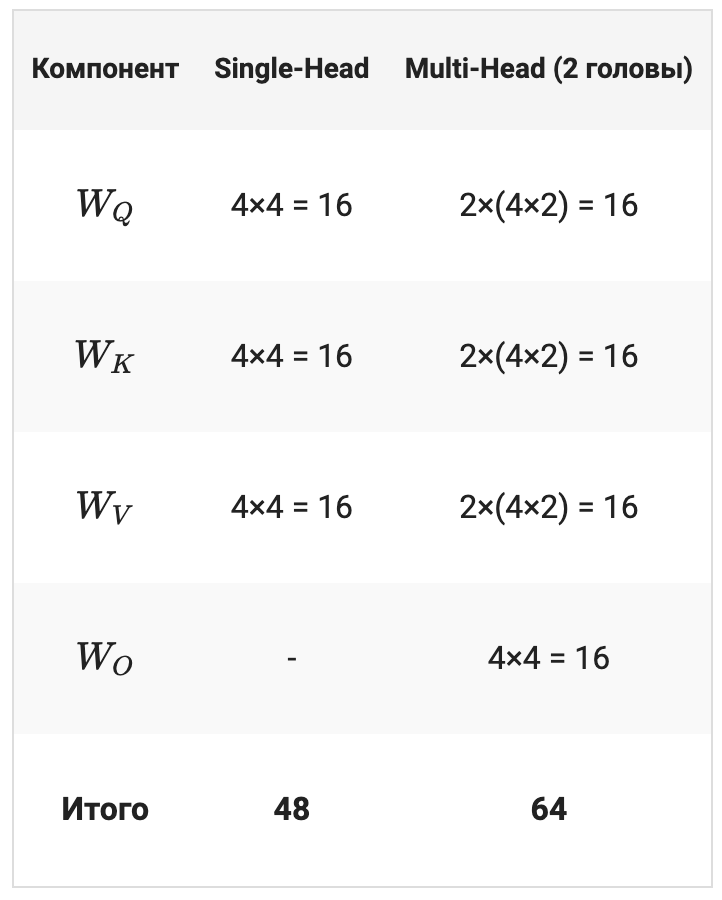

**Вывод:** Multi-Head добавляет всего 16 параметров ($W_O$), но даёт 2 специализированных механизма внимания вместо одного!

Раньше у нас была формула: $Q=X@W_Q$, причем $[3\times4]@[4\times4]=[3\times4]$

Теперь же формула та же, но размерность изменится:
$[3\times4]@[4\times2]=[3\times2]$

То есть длина соответствующего вектора в результирующей матрице равна длине `head_dim`

Проведя соответствующие вычисления, получаем:
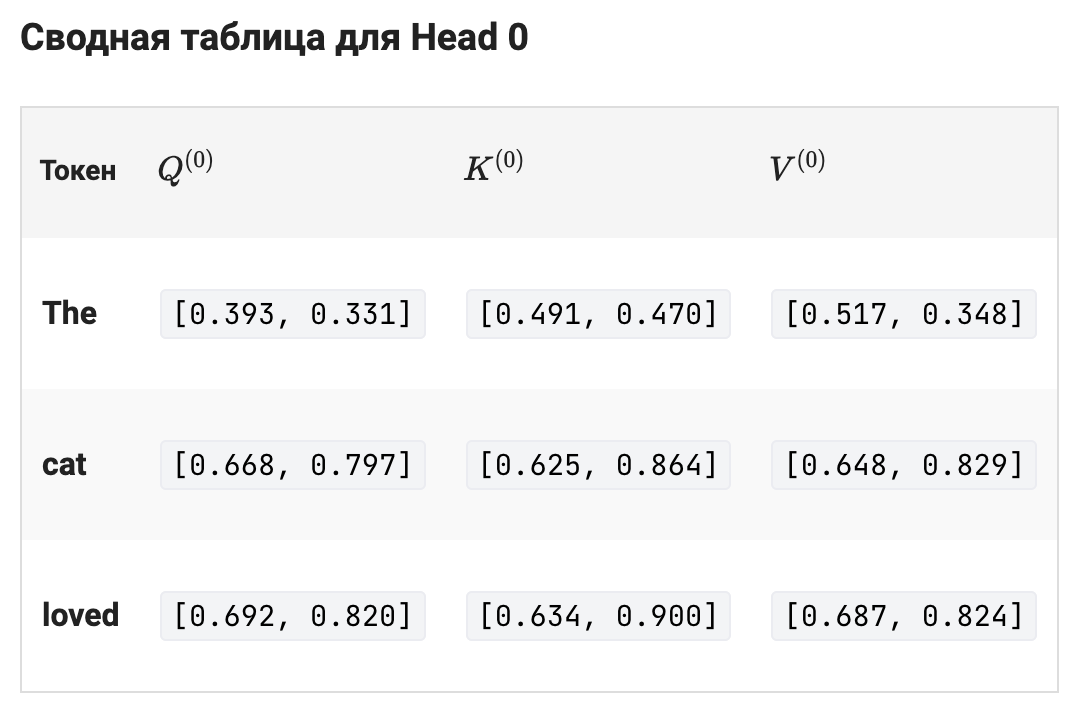

Подсчитаем теперь `Scores` - формула та же, только масштабирование будет не на `embed_dim`, а на `head_dim`:

$$Scores^0=\frac{Q^0@{K^0}^T}{\sqrt{head\_dim}} = \frac{[3\times2]@[2\times 3]}{\sqrt{2}} = \frac{[3\times3]}{\sqrt{2}}$$

**Почему это важно:** Масштабирование по `head_dim` (а не `embed_dim`) обеспечивает стабильность градиентов для каждой головы независимо.

Итого получаем:

$$
\mathrm{Scores}^{(0)} =
\begin{bmatrix}
0.2465 & 0.3759 & 0.3869 \\
0.4968 & 0.7821 & 0.8067 \\
0.5128 & 0.8068 & 0.8321
\end{bmatrix}
$$

**Важно:** Размерность матрицы Scores не изменилась ([3×3]), потому что она зависит от количества токенов, а не от размерности векторов!

Применяя softmax получаем:

$$
\mathrm{Weights}^{(0)} =
\begin{bmatrix}
0.3040 & 0.3461 & 0.3499 \\
0.2707 & 0.3601 & 0.3691 \\
0.2690 & 0.3609 & 0.3701
\end{bmatrix}
$$

И наконец находим контекстные векора $Context = Weights@V = [3\times3]@[3\times2]=[3\times2]$ 

**Контекстные векторы для Head 0**

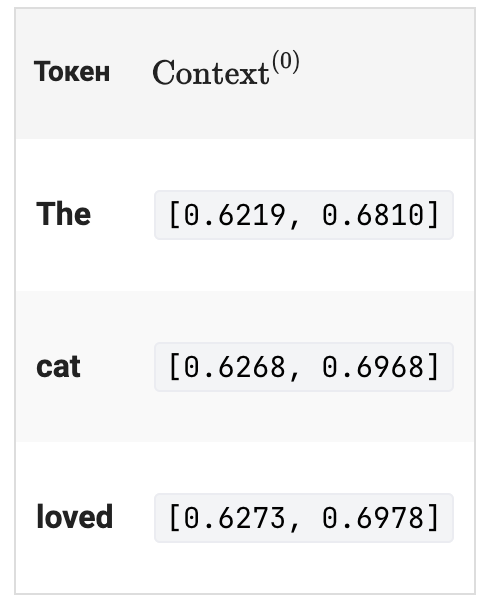

Для Head 1 вычисления полностью аналогины Head 0

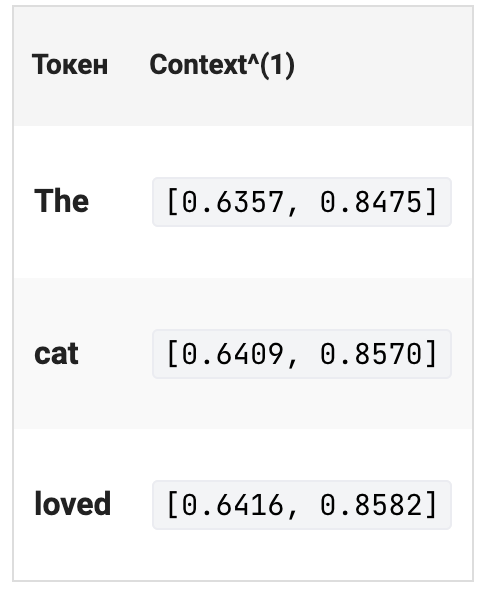

**Важно:** $Context^1$ отличается от $Context^0$, так как изначально разные весовые матрицы

**В Multi-Head нужно объединить результаты всех голов Head 0 и Head 1.** Я надеюсь, что теперь явно видно, в чем идея Multi-Head.

$$Concat = [Context^0, Context^1] = [3\times4]$$

$$
\mathrm{Concat} =
\begin{bmatrix}
0.6219 & 0.6810 & 0.6357 & 0.8475 \\
0.6268 & 0.6968 & 0.6409 & 0.8570 \\
0.6273 & 0.6978 & 0.6416 & 0.8582
\end{bmatrix}
$$

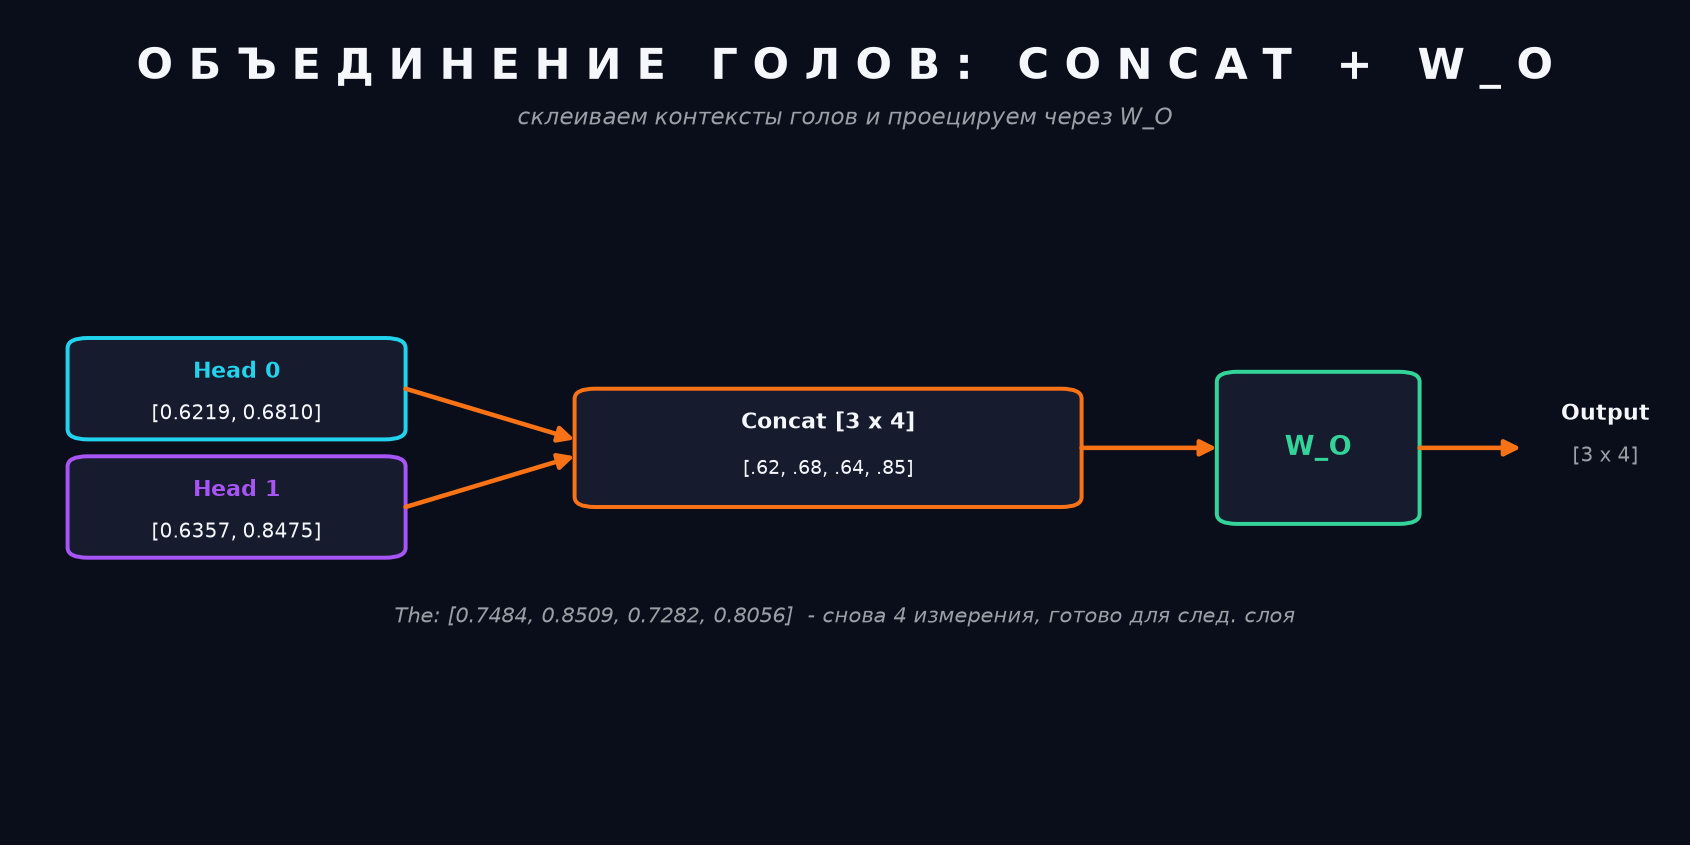

**В Single-Head не было этого шага! Выход после внимания сразу использовался дальше. Но теперь нужно спроецировать конкатенированные векторы через матрицу $W_O$**

**Зачем:**

1. **Смешать информацию** от всех голов
2. **Научиться комбинировать** результаты голов оптимальным образом
3. **Подготовить выход** для следующего слоя

Формула:
$$Output = Concat @ W_O = [3\times4]@[4\times4]=[3\times4]$$

$$
W_O =
\begin{bmatrix}
0.5 & 0.2 & 0.1 & 0.3 \\
0.3 & 0.6 & 0.2 & 0.1 \\
0.1 & 0.1 & 0.7 & 0.2 \\
0.2 & 0.3 & 0.1 & 0.5
\end{bmatrix}
$$

Итого, получаем:

$$
\mathrm{Output} =
\begin{bmatrix}
0.7484 & 0.8509 & 0.7282 & 0.8056 \\
0.7579 & 0.8647 & 0.7364 & 0.8144 \\
0.7588 & 0.8659 & 0.7372 & 0.8154
\end{bmatrix}
$$

В нашей модели мы сделали упрощённую Multi-Head архитектуру - всего 2 головы. Это необходимо для лучшего понимания механики процесса. В реальных же моделях, таких как GPT-3, используется намного больше «голов».

Вот данные из оригинальной статьи "Language Models are Few-Shot Learners" (2020):

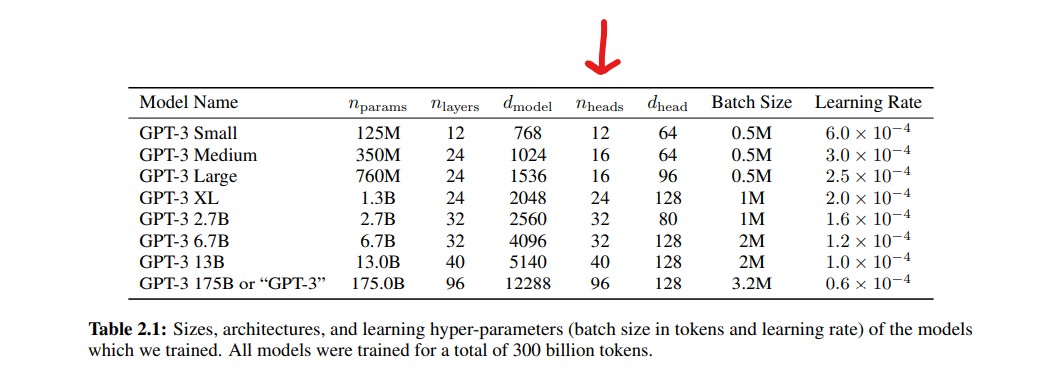

Размерность каждой головы:

$$head\_dim = \frac{embed\_dim}{num\_heads}=\frac{12288}{96}=128$$

Перейдём к реализации в файле `attention_multihead.py`